Given that the field has not converged on gold-standard assessment metrics, ere, we visualize the predictions in embedding space and assess via the "eyeball test". This tends to be reasonably indicative of model's predictive performance, though more qualitative than quantitative. 

We use PLS models fit on the specific test conditions from Notebook 06_PRELIM for visualization. 

In [1]:
import warnings

warnings.resetwarnings()

warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    message=r".*__version__ is deprecated.*"
)

warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    message=r"Observation names are not unique.*"
)

warnings.filterwarnings(
    "ignore",
    module=r"scanpy(\..*)?$"
)

warnings.filterwarnings(
    "ignore",
    module=r"anndata(\..*)?$"
)

warnings.filterwarnings("ignore", module=r"scanpy(\..*)?$")
warnings.filterwarnings("ignore", module=r"anndata(\..*)?$")
warnings.filterwarnings("ignore", message="Observation names are not unique.*")
warnings.filterwarnings("ignore", message="`__version__` is deprecated.*")
warnings.filterwarnings('ignore', category=FutureWarning, module='scanpy')
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=ImportWarning)

from anndata._warnings import ImplicitModificationWarning
warnings.filterwarnings(
    "ignore",
    category=ImplicitModificationWarning
)

In [2]:
import os
import sys
import warnings
from contextlib import contextmanager
import copy

from tqdm import trange

import numpy as np
import pandas as pd
import scanpy as sc
from scipy.spatial.distance import cosine as cosine_distance


import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
sns.set_context(
    "paper",
    rc={
        "axes.labelsize": 18,
        "axes.titlesize": 20,
        "legend.fontsize": 12,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
    }
)

import sys
sys.path.insert(1, '../../.')
from McCauley_utils import all_data

sys.path.insert(1, '../../../.') 
from notebook_utils import get_split, pb_y_pred

sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
from scLEMBAS import latent_separation as ls
from scLEMBAS.metrics import distances

/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
seed = 888
data_path = '/home/hmbaghda/orcd/pool/scLEMBAS/analysis'
author = 'McCauley'

n_cores = 30
os.environ["OMP_NUM_THREADS"] = str(1)
os.environ["MKL_NUM_THREADS"] = str(1)
os.environ["OPENBLAS_NUM_THREADS"] = str(1)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(1)
os.environ["NUMEXPR_NUM_THREADS"] = str(1)

In [4]:
(sn_ppis, tf_adata, adata, expr, source_label, target_label, weight_label, 
 stimulation_label, inhibition_label, cat_col, pert_col, ctrl_pert) = all_data

merged_adatas = io.read_pickled_object(
    os.path.join(data_path, 'processed', '{}_scLEMBAS_model_predictions.pickle'.format(author))
)

cspm = io.read_pickled_object(os.path.join(data_path, 'interim', '{}_test_condition_PLS_models.pickle'))

In [5]:
n_folds = 5
ls_label_dict = {
    'pls': 'LV', 
    'pca': 'PC'
}

# Test Predictions

In [6]:
def load_test_tfadata(fold):
    key = 'none_{}'.format(fold)
    tf_adata_merged = merged_adatas[key].copy()

    split = get_split(fold, author)
    test_conds = split['test_conds']

    test_cond_mask = tf_adata_merged.obs.condition.isin(test_conds)
    tf_adata_test = tf_adata_merged[test_cond_mask,:].copy()
    assert 'predicted_ctrl' not in tf_adata_test.obs.batch, 'Unexpected training predictions present'

    predicted_mask = (tf_adata_test.obs.batch == 'predicted')

    tf_adata_predicted = tf_adata_test[predicted_mask, :].copy()
    tf_adata_actual = tf_adata_test[~predicted_mask, :].copy()
    assert len(np.where(tf_adata.obs.condition.isin(test_conds))[0]) == tf_adata_actual.shape[0], 'Incorrect subsetting of actual data'

    return tf_adata_actual, tf_adata_predicted


def plot_fold_column_(tf_adata_actual, tf_adata_predicted, 
                     ls, group_col, ax, min_points_kde = 75, is_last_col = False):

    adata_dict = {
        'Actual': tf_adata_actual,
        'Predicted': tf_adata_predicted
    }

    cats = None

    for (i, (adata_type, adata)) in enumerate(adata_dict.items()):

        viz_df = pd.DataFrame(adata.obsm['X_{}'.format(ls)])
        viz_df.columns = ['{}{}'.format(ls_label_dict[ls], i+1) for i in range(viz_df.shape[1])]

        viz_df[group_col] = adata.obs[group_col].astype(str).apply(lambda x: x.replace('^', ', ')).tolist()
        viz_df[group_col].apply
        cats = sorted(viz_df[group_col].unique())
        viz_df[group_col] = pd.Categorical(viz_df[group_col],
                                           categories = cats, ordered = True)

        # --- KDE for groups that can support it; scatter fallback for tiny / singular groups ---

        small_cats = []
        for cat in cats:
            tmp = viz_df[viz_df[group_col] == cat]

            # too few points
            if tmp.shape[0] < min_points_kde:
                small_cats.append(cat)
                continue

            # singular / near-singular geometry (no 2D contour possible)
            xvar = np.var(tmp['{}1'.format(ls_label_dict[ls])].values)
            yvar = np.var(tmp['{}2'.format(ls_label_dict[ls])].values)
            if (xvar <= 1e-12) or (yvar <= 1e-12):
                small_cats.append(cat)

        viz_df_kde = viz_df[~viz_df[group_col].isin(small_cats)]

        if viz_df_kde.shape[0] > 0:
            sns.kdeplot(data = viz_df_kde,
                        x = '{}1'.format(ls_label_dict[ls]),
                        y = '{}2'.format(ls_label_dict[ls]),
                        hue = group_col, fill = False, levels = 5,
                        warn_singular = False,
                        ax = ax[i])

        # scatter overlay for small / singular groups (so they never disappear)
        palette = sns.color_palette(n_colors = len(cats))
        color_map = {cat: color for (cat, color) in zip(cats, palette)}

        for cat in small_cats:
            tmp = viz_df[viz_df[group_col] == cat]
            ax[i].scatter(tmp['{}1'.format(ls_label_dict[ls])],
                          tmp['{}2'.format(ls_label_dict[ls])],
                          s = 12, alpha = 0.9,
                          color = color_map[cat])

        # titles: only top row
        if i == 0:
            ax[i].set_title('Fold: {}'.format(fold + 1))
        else:
            ax[i].set_title('')

        # clear seaborn auto-legend
        ax[i].legend_.remove() if ax[i].legend_ is not None else None

        # right-side y-axis labels only on final column
        if is_last_col:
            ax_r = ax[i].twinx()                 
            ax_r.set_ylabel(adata_type, labelpad = 20)
            ax_r.set_yticks([])              
            ax_r.tick_params(right=False)
            ax_r.spines['right'].set_visible(False)
#         else:
#             ax[i].set_ylabel('')

    # ensure smae bounds (robust quantiles)
    xmin, xmax, ymin, ymax = np.inf, -np.inf, np.inf, -np.inf

    q_lo = 0.005
    q_hi = 0.995

    for (adata_type, adata) in adata_dict.items():
        X = adata.obsm['X_{}'.format(ls)]

        x_lo = np.quantile(X[:, 0], q_lo)
        x_hi = np.quantile(X[:, 0], q_hi)
        y_lo = np.quantile(X[:, 1], q_lo)
        y_hi = np.quantile(X[:, 1], q_hi)

        if x_lo < xmin:
            xmin = x_lo
        if x_hi > xmax:
            xmax = x_hi
        if y_lo < ymin:
            ymin = y_lo
        if y_hi > ymax:
            ymax = y_hi

    # small padding
    pad = 0.15
    dx = (xmax - xmin) * pad
    dy = (ymax - ymin) * pad
    xmin = xmin - dx
    xmax = xmax + dx
    ymin = ymin - dy
    ymax = ymax + dy

    for j in range(2):
        ax[j].set_xlim(xmin, xmax)
        ax[j].set_ylim(ymin, ymax)

    # legend (only once per column, on top axis)
    handles = []
    labels = []
    palette = sns.color_palette(n_colors = len(cats))
    for color, cat in zip(palette, cats):
        handles.append(Line2D([0], [0], color = color, lw = 2))
        labels.append(cat)
    ax[0].legend(handles = handles, labels = labels, title = '')

    return cats

In [7]:
def clear_tfadata(tf_adata_actual, tf_adata_predicted):
    cols = [pert_col, cat_col, 'condition', 'batch', 'barcode']
    tf_adata_actual.obs = tf_adata_actual.obs[cols].copy()
    tf_adata_predicted.obs = tf_adata_predicted.obs[cols].copy()

    del tf_adata_actual.obsm['X_pls'], tf_adata_actual.obsm['X_umap_pls']
    del tf_adata_predicted.obsm['X_pls'], tf_adata_predicted.obsm['X_umap_pls']
    
    return tf_adata_actual, tf_adata_predicted


def test_condition_specific_pls_fits(tf_adata_actual, tf_adata_predicted, fold, baseline = False):
    """Refits PLS on the only the actual test conditions specifically separated by condition, 
    rather than on all data separated by perturbation """
    
    if not baseline:
        tf_adata_actual, tf_adata_predicted = clear_tfadata(tf_adata_actual, tf_adata_predicted)
    pls_model = cspm[fold]
    
    X_actual_pls = pls_model.transform(tf_adata_actual.X)
    tf_adata_actual.obsm['X_pls'] = X_actual_pls
    
    X_pred_pls = pls_model.transform(tf_adata_predicted.X)
    tf_adata_predicted.obsm['X_pls'] = X_pred_pls
    
    return tf_adata_actual, tf_adata_predicted

# redfine plotting with this additional step
def plot_fold_column(fold, ls, group_col, ax, min_points_kde = 75, is_last_col = False):
    tf_adata_actual, tf_adata_predicted = load_test_tfadata(fold)
    tf_adata_actual, tf_adata_predicted = test_condition_specific_pls_fits(tf_adata_actual, tf_adata_predicted, fold, baseline = False)
    cats = plot_fold_column_(tf_adata_actual, tf_adata_predicted, 
                     ls, group_col, ax, min_points_kde, is_last_col)
    return cats


100%|█████████████████████████████████████████████| 5/5 [00:19<00:00,  3.93s/it]


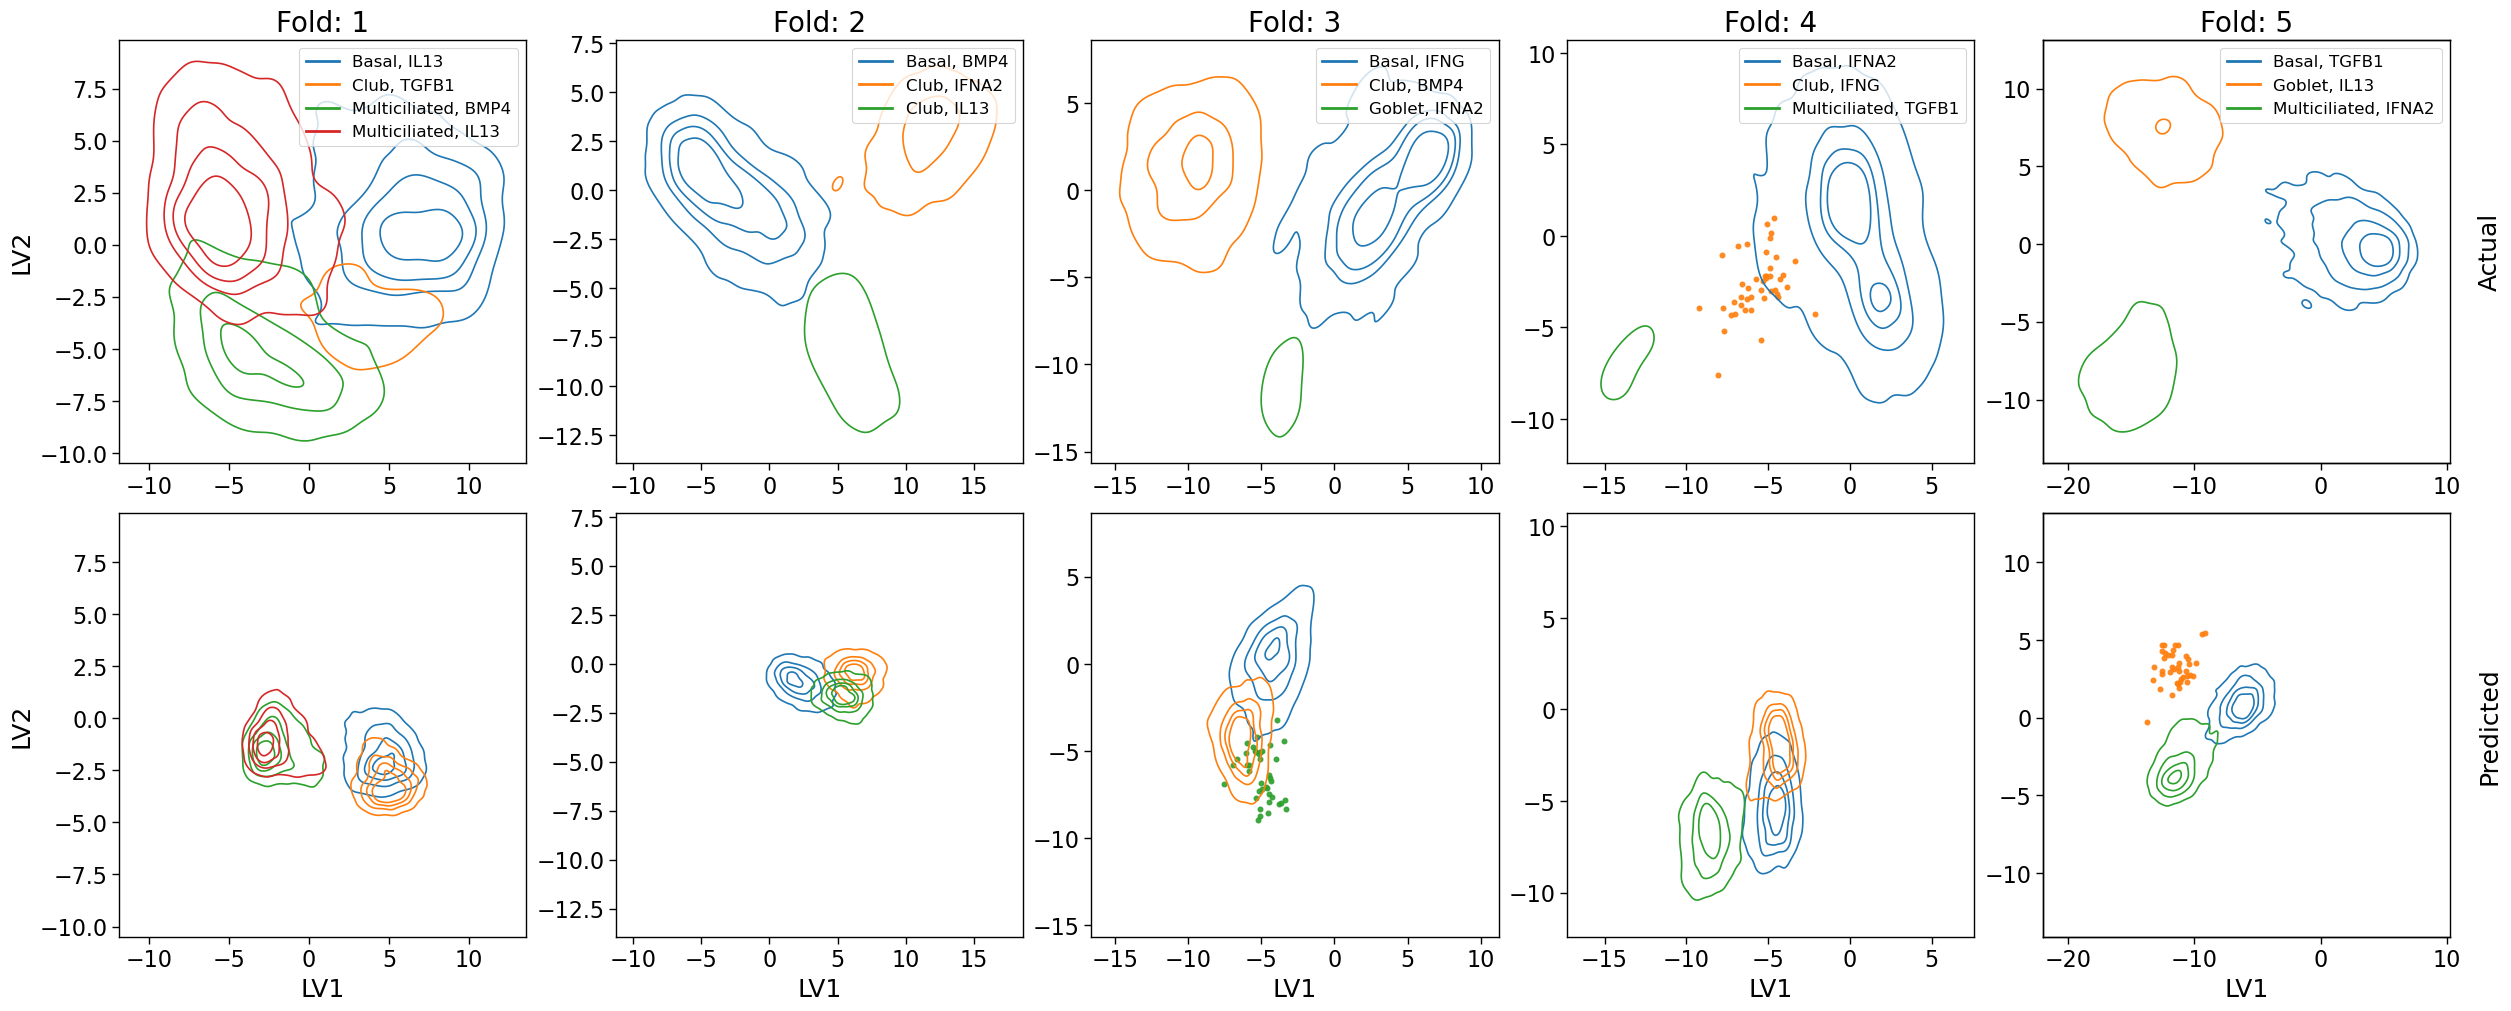

In [8]:
fig, ax = plt.subplots(nrows = 2, ncols = n_folds,
                       figsize = (5 * n_folds, 10),
                       constrained_layout = True)
if n_folds == 1:
    ax = np.array(ax).reshape(2, 1)

for fold in trange(n_folds):
    plot_fold_column(fold = fold,
                     ls = 'pls',
                     group_col = 'condition',
                     ax = ax[:, fold],
                     min_points_kde = 50, 
                     is_last_col = (fold == n_folds - 1))

for i in range(ax.shape[0]): 
    for j in range(ax.shape[1]):
        if j == 0:
            ax[i, j].set_ylabel('LV2')
        else:
            ax[i,j].set_ylabel('')

        if i == (ax.shape[0]) - 1:
            ax[i, j].set_xlabel('LV1')
        else:
            ax[i,j].set_xlabel('')

These visuals demonstrate the decent relative positioning of condition-specific test predictions relative to actual. Additionally:

- All PLS model fits are significant, so this isn't just fitting noise
- Predictions are projected into the actual data space (not jointly embedded), making this a reasonably stringent eyeball test metric.